# Regresión logística paso a paso
### Semana 8 · FIA 94103 · Fundamentos de IA

Este notebook es el equivalente, para regresión **logística**, de `Semana_7/Matematicas/regresion_lineal_paso_a_paso.ipynb`: reconstruye la matemática con una sola variable predictora, sobre datos reales de `StudentsPerformance.csv`. En vez de predecir un número (`writing score`), predecimos algo binario: **¿el estudiante aprueba matemáticas?** (`math score >= 60`), usando como única variable `reading score`.

**Contenido:**
1. Exploración de los datos
2. El modelo: por qué no sirve la regresión lineal, y la función sigmoide
3. Ajuste "a mano" por máxima verosimilitud (búsqueda en grilla, muestra de 10 estudiantes)
4. Visualización de la curva ajustada
5. La misma idea sobre las 1000 filas (ajuste real con `statsmodels`)
6. Verificación con `scikit-learn`
7. Interpretar el coeficiente: *odds ratio*
8. Evaluar el modelo: matriz de confusión, exactitud, precisión, sensibilidad
9. Predicción para un estudiante nuevo
10. Conclusiones

## 0. Librerías

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

plt.rcParams['figure.figsize'] = (7, 5)
np.set_printoptions(precision=4, suppress=True)

## 1. Exploración de los datos

Creamos la variable a predecir (`aprueba_mate`) y miramos cómo se distribuye `reading score` entre quienes aprueban y quienes no — el mismo primer paso ("explorar") del flujo que ya conoces de la regresión lineal.

In [2]:
df = pd.read_csv('../StudentsPerformance.csv')
df.columns = [c.strip() for c in df.columns]
df['aprueba_mate'] = (df['math score'] >= 60).astype(int)

print('Filas:', len(df))
print(df['aprueba_mate'].value_counts())
df[['reading score', 'math score', 'aprueba_mate']].head()

Filas: 1000
aprueba_mate
1    677
0    323
Name: count, dtype: int64


,reading score,math score,aprueba_mate
0,72,72,1
1,90,69,1
2,95,90,1
3,57,47,0
4,78,76,1


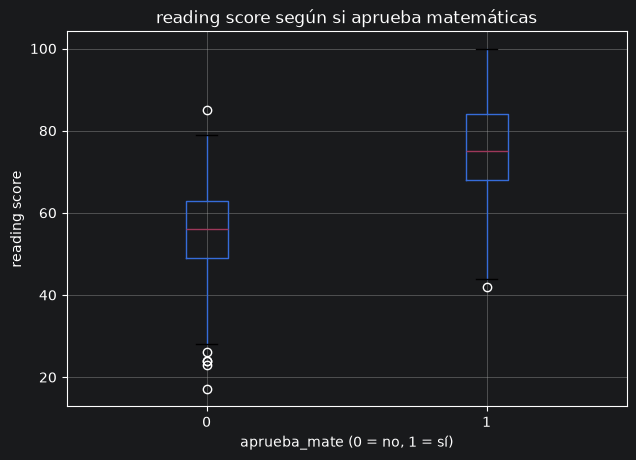

In [3]:
df.boxplot(column='reading score', by='aprueba_mate')
plt.title('reading score según si aprueba matemáticas')
plt.suptitle('')
plt.xlabel('aprueba_mate (0 = no, 1 = sí)')
plt.ylabel('reading score')
plt.show()

Los que aprueban matemáticas tienden a tener `reading score` más alto — hay una señal visible antes de ajustar nada, igual que el scatter con tendencia lineal que revisaste en la Semana 7.

## 2. El modelo

Si ajustáramos $Y = b_0 + b_1 X$ con $Y\in\{0,1\}$, la recta podría devolver predicciones sin sentido (mayores a 1 o negativas). En vez de eso, combinamos las variables igual que antes,

$$z = b_0 + b_1 x$$

pero pasamos $z$ por la **función sigmoide**, que siempre da un valor entre 0 y 1:

$$P(Y=1\mid x) = \frac{1}{1+e^{-z}}$$

Despejando $z$ se obtiene el **logit**: $z = \ln\!\big(\frac{P}{1-P}\big)$. El modelo sigue siendo una combinación lineal — solo que de la probabilidad transformada (el *logit*), no de la probabilidad misma.

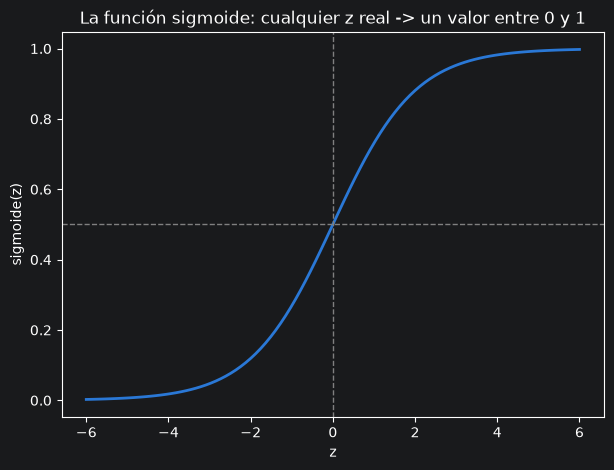

In [4]:
def sigmoide(z):
    return 1 / (1 + np.exp(-z))

zs = np.linspace(-6, 6, 100)
plt.plot(zs, sigmoide(zs), color='#2a78d6', linewidth=2)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('z')
plt.ylabel('sigmoide(z)')
plt.title('La función sigmoide: cualquier z real -> un valor entre 0 y 1')
plt.show()

## 3. Ajuste "a mano": máxima verosimilitud

En regresión lineal, `b0` y `b1` salían de una **fórmula cerrada** (mínimos cuadrados). En regresión logística **no existe fórmula cerrada**: se buscan los `b0`, `b1` que hacen más "creíbles" los datos observados, es decir, que **maximizan la verosimilitud**:

$$\ell(b_0,b_1) = \sum_{i=1}^n \Big[y_i \ln(p_i) + (1-y_i)\ln(1-p_i)\Big], \qquad p_i = \text{sigmoide}(b_0+b_1 x_i)$$

Si $y_i=1$ (aprobó), un buen ajuste debe dar $p_i$ cercano a 1; si $y_i=0$, debe dar $p_i$ cercano a 0. Con una muestra pequeña de 10 estudiantes, probamos varias combinaciones de $(b_0,b_1)$ "a mano" (una búsqueda en grilla) y nos quedamos con la que da la log-verosimilitud más alta — el mismo principio que usa el algoritmo real, solo que aquí probamos combinaciones nosotros en vez de dejar que un optimizador las busque.

**Nota — por qué no usamos simplemente `df.head(10)`:** con las primeras 10 filas del archivo, `reading score` separa *perfectamente* a quienes aprueban de quienes no (todos los que aprueban tienen `reading >= 64`; todos los que no aprueban tienen `reading <= 60`). Cuando una sola variable separa los datos sin ningún solapamiento, no existe un $(b_0,b_1)$ finito que maximice la verosimilitud: el optimizador puede seguir "empujando" los coeficientes hacia el infinito sin dejar de mejorar el ajuste. `statsmodels` avisa esto con un `PerfectSeparationWarning` (y un `ConvergenceWarning`, porque nunca converge a un valor finito) — es un problema real y conocido de la regresión logística con muestras chicas o muy separables, no un error de código. Por eso elegimos aquí una muestra (filas 30 a 39) donde las dos clases se **solapan**: hay estudiantes con `reading score` parecido que aprobaron y otros que no.

In [5]:
muestra = df.iloc[30:40].copy()
x10 = muestra['reading score'].to_numpy(dtype=float)
y10 = muestra['aprueba_mate'].to_numpy(dtype=float)

print(muestra[['reading score', 'math score', 'aprueba_mate']])

    reading score  math score  aprueba_mate
30             74          69             1
31             65          63             1
32             72          56             0
33             42          40             0
34             87          97             1
35             81          81             1
36             81          74             1
37             64          50             0
38             90          75             1
39             56          57             0


In [6]:
def log_verosimilitud(b0, b1, x, y):
    z = b0 + b1 * x
    p = sigmoide(z)
    p = np.clip(p, 1e-10, 1 - 1e-10)  # evita log(0)
    return np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

candidatos_b0 = np.arange(-25, 5, 1.0)
candidatos_b1 = np.arange(-0.1, 0.6, 0.02)

mejor_ll = -np.inf
mejor_b0, mejor_b1 = None, None
for b0c in candidatos_b0:
    for b1c in candidatos_b1:
        ll = log_verosimilitud(b0c, b1c, x10, y10)
        if ll > mejor_ll:
            mejor_ll = ll
            mejor_b0, mejor_b1 = b0c, b1c

print(f'Mejor combinación encontrada en la grilla: b0={mejor_b0:.2f}  b1={mejor_b1:.2f}')
print(f'Log-verosimilitud = {mejor_ll:.4f}')

Mejor combinación encontrada en la grilla: b0=-15.00  b1=0.22
Log-verosimilitud = -3.0920


In [7]:
# Comparamos contra el ajuste real (optimizador iterativo) sobre la misma muestra de 10
X10 = sm.add_constant(x10)
modelo10 = sm.Logit(y10, X10).fit(disp=0)
print(f"¿Convergió a un óptimo finito? {modelo10.mle_retvals['converged']}")
print(f"statsmodels sobre la muestra de 10 -> b0={modelo10.params[0]:.2f}  b1={modelo10.params[1]:.2f}")
print(f"Log-verosimilitud (óptimo real) = {modelo10.llf:.4f}")
print('\nLa grilla "a mano" se acerca al óptimo real, y el optimizador iterativo lo encuentra con más precisión.')

¿Convergió a un óptimo finito? True
statsmodels sobre la muestra de 10 -> b0=-15.72  b1=0.23
Log-verosimilitud (óptimo real) = -3.0893

La grilla "a mano" se acerca al óptimo real, y el optimizador iterativo lo encuentra con más precisión.


## 4. Visualización de la curva ajustada (muestra de 10)

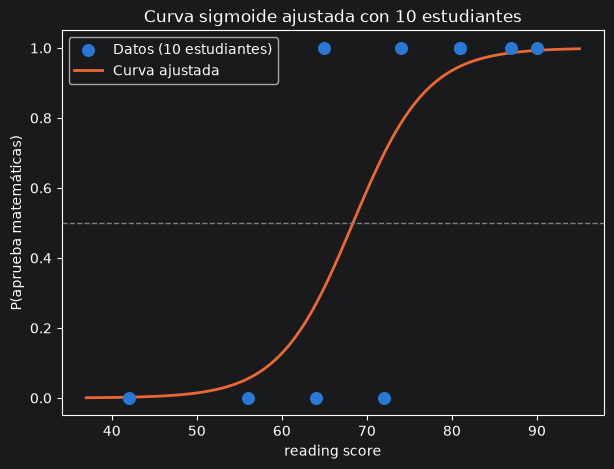

In [8]:
b0_10, b1_10 = modelo10.params
xs_curva = np.linspace(x10.min() - 5, x10.max() + 5, 100)

plt.scatter(x10, y10, color='#2a78d6', s=70, zorder=3, label='Datos (10 estudiantes)')
plt.plot(xs_curva, sigmoide(b0_10 + b1_10 * xs_curva), color='#eb6834', linewidth=2, label='Curva ajustada')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.xlabel('reading score')
plt.ylabel('P(aprueba matemáticas)')
plt.title('Curva sigmoide ajustada con 10 estudiantes')
plt.legend()
plt.show()

## 5. La misma idea sobre las 1000 filas

Con 10 puntos, la curva puede verse "demasiado perfecta" (fácil de separar). Ajustamos el modelo real con `statsmodels` sobre el dataset completo — el optimizador resuelve por iteración el mismo problema de máxima verosimilitud.

In [9]:
X = sm.add_constant(df['reading score'])
y = df['aprueba_mate']

modelo = sm.Logit(y, X).fit(disp=0)
print(modelo.summary())

                           Logit Regression Results                           
Dep. Variable:           aprueba_mate   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      998
Method:                           MLE   Df Model:                            1
Date:                Wed, 19 Aug 2026   Pseudo R-squ.:                  0.4168
Time:                        10:27:19   Log-Likelihood:                -366.88
converged:                       True   LL-Null:                       -629.11
Covariance Type:            nonrobust   LLR p-value:                4.530e-116
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -10.2254      0.702    -14.565      0.000     -11.601      -8.849
reading score     0.1672      0.011     15.334      0.000       0.146       0.189


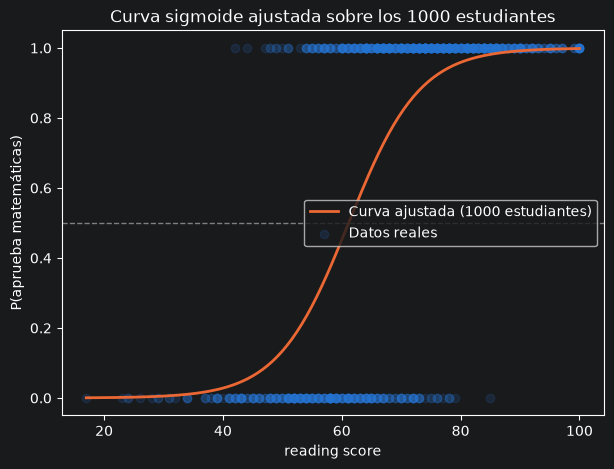

In [10]:
b0, b1 = modelo.params
xs_full = np.linspace(df['reading score'].min(), df['reading score'].max(), 200)

plt.plot(xs_full, sigmoide(b0 + b1 * xs_full), color='#eb6834', linewidth=2, label='Curva ajustada (1000 estudiantes)')
plt.scatter(df['reading score'], df['aprueba_mate'], alpha=0.15, color='#2a78d6', label='Datos reales')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.xlabel('reading score')
plt.ylabel('P(aprueba matemáticas)')
plt.title('Curva sigmoide ajustada sobre los 1000 estudiantes')
plt.legend()
plt.show()

El coeficiente `b1` (positivo y con p-value prácticamente cero) confirma lo que ya se veía en el boxplot: a mayor `reading score`, mayor probabilidad de aprobar matemáticas, y ese efecto es estadísticamente significativo — la misma lógica de H0/H1 y p-value de la regresión lineal, aplicada aquí a través de la **prueba de Wald** en vez del estadístico *t*.

## 6. Verificación con `scikit-learn`

`LogisticRegression().fit(X, y)` resuelve el mismo problema de máxima verosimilitud con su propio optimizador; comprobamos que llega a coeficientes prácticamente iguales a los de `statsmodels`.

In [11]:
X_sk = df[['reading score']].to_numpy(dtype=float)
y_sk = df['aprueba_mate'].to_numpy()

modelo_sk = LogisticRegression()
modelo_sk.fit(X_sk, y_sk)

print(f'statsmodels -> b0={b0:.4f}  b1={b1:.4f}')
print(f'scikit-learn -> b0={modelo_sk.intercept_[0]:.4f}  b1={modelo_sk.coef_[0][0]:.4f}')

statsmodels -> b0=-10.2254  b1=0.1672
scikit-learn -> b0=-10.2241  b1=0.1672


Pueden diferir en la tercera o cuarta cifra decimal: cada librería usa un optimizador distinto (y `scikit-learn` aplica una pequeña regularización por defecto), pero ambos apuntan al mismo óptimo.

## 7. Interpretar el coeficiente: *odds ratio*

`b1` no se lee en "puntos de probabilidad": se interpreta a través de los **momios (odds)**, $\text{odds}=p/(1-p)$. El **odds ratio** es $e^{b_1}$: cuánto se multiplican los momios del evento por cada unidad adicional de `x`.

In [12]:
odds_ratio = np.exp(b1)
print(f'b1 = {b1:.5f}')
print(f'odds ratio = e^b1 = {odds_ratio:.4f}')
print(f'\nPor cada punto extra de reading score, los momios de aprobar matemáticas se multiplican por {odds_ratio:.2f} (suben ~{(odds_ratio-1)*100:.1f}%).')

b1 = 0.16721
odds ratio = e^b1 = 1.1820

Por cada punto extra de reading score, los momios de aprobar matemáticas se multiplican por 1.18 (suben ~18.2%).


## 8. Evaluar el modelo

Como `Y` es categórica, no se usa R²: se convierte la probabilidad en una decisión (umbral 0.5) y se compara contra la clase real con una **matriz de confusión**.

In [13]:
prob_predicha = modelo.predict(X)
clase_predicha = (prob_predicha >= 0.5).astype(int)

cm = confusion_matrix(y, clase_predicha)
print(pd.DataFrame(cm, index=['Real: no aprueba', 'Real: aprueba'], columns=['Predicho: no aprueba', 'Predicho: aprueba']))

exactitud = accuracy_score(y, clase_predicha)
precision = precision_score(y, clase_predicha)
recall = recall_score(y, clase_predicha)
print(f'\nExactitud (accuracy)  = {exactitud:.4f}')
print(f'Precisión             = {precision:.4f}')
print(f'Sensibilidad (recall) = {recall:.4f}')

                  Predicho: no aprueba  Predicho: aprueba
Real: no aprueba                   227                 96
Real: aprueba                       72                605

Exactitud (accuracy)  = 0.8320
Precisión             = 0.8631
Sensibilidad (recall) = 0.8936


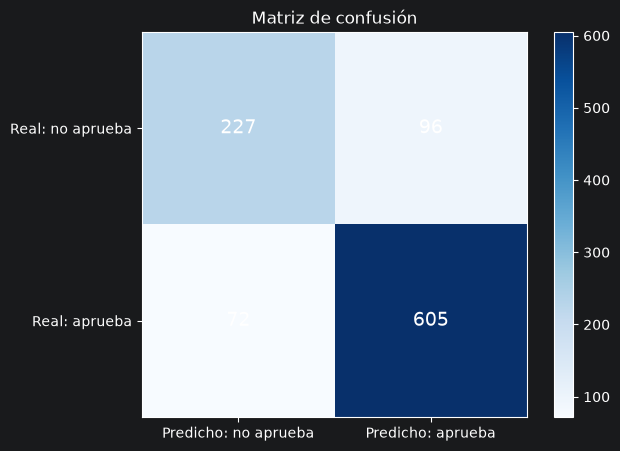

In [14]:
plt.imshow(cm, cmap='Blues')
plt.xticks([0, 1], ['Predicho: no aprueba', 'Predicho: aprueba'])
plt.yticks([0, 1], ['Real: no aprueba', 'Real: aprueba'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14)
plt.title('Matriz de confusión')
plt.colorbar()
plt.show()

## 9. Predicción para un estudiante nuevo

In [15]:
for reading_nuevo in [50, 65, 80]:
    z_nuevo = b0 + b1 * reading_nuevo
    p_nuevo = sigmoide(z_nuevo)
    decision = 'aprueba' if p_nuevo >= 0.5 else 'no aprueba'
    print(f'reading={reading_nuevo} -> z={z_nuevo:.4f}  P(aprueba)={p_nuevo:.4f}  ({p_nuevo*100:.1f}%)  -> se clasifica como "{decision}"')

reading=50 -> z=-1.8650  P(aprueba)=0.1341  (13.4%)  -> se clasifica como "no aprueba"
reading=65 -> z=0.6431  P(aprueba)=0.6555  (65.5%)  -> se clasifica como "aprueba"
reading=80 -> z=3.1513  P(aprueba)=0.9590  (95.9%)  -> se clasifica como "aprueba"


## 10. Conclusiones

1. **La sigmoide reemplaza a la recta** cuando `Y` es binaria: garantiza que la predicción quede siempre entre 0 y 1.
2. **No hay fórmula cerrada**: los coeficientes se buscan maximizando la log-verosimilitud con un optimizador iterativo, no con álgebra directa como en mínimos cuadrados.
3. **El modelo es lineal en el logit**, no en la probabilidad — por eso `b1` se interpreta mejor como *odds ratio* ($e^{b_1}$) que como un cambio directo en puntos de probabilidad.
4. **`statsmodels` y `scikit-learn` llegan al mismo óptimo** por caminos numéricos distintos — la ventaja de la librería es la velocidad y la estabilidad del optimizador, no la matemática de fondo.
5. **Se evalúa distinto que la regresión lineal**: matriz de confusión, exactitud, precisión y sensibilidad, en vez de R².